# Parallel Adapter 交互教学

配套 lecture: [../lectures/04-parallel-adapter.md](../lectures/04-parallel-adapter.md)

本 notebook 演示:
1. 串联 vs 并联结构差异
2. 训练后权重确实不同
3. Parallel Adapter 去掉非线性 = LoRA

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

src = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src))

from parallel_minimal import ParallelAdapterGPT2
from pfeiffer_minimal import PfeifferGPT2
from common import print_param_summary

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 串联 vs 并联 mini training

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


C:\Users\ericp\AppData\Local\Temp\ipykernel_34784\331758562.py:32: UserWarning: Glyph 20018 (\N{CJK UNIFIED IDEOGRAPH-4E32}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_34784\331758562.py:32: UserWarning: Glyph 32852 (\N{CJK UNIFIED IDEOGRAPH-8054}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_34784\331758562.py:32: UserWarning: Glyph 24182 (\N{CJK UNIFIED IDEOGRAPH-5E76}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20018 (\N{CJK UNIFIED IDEOGRAPH-4E32}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython

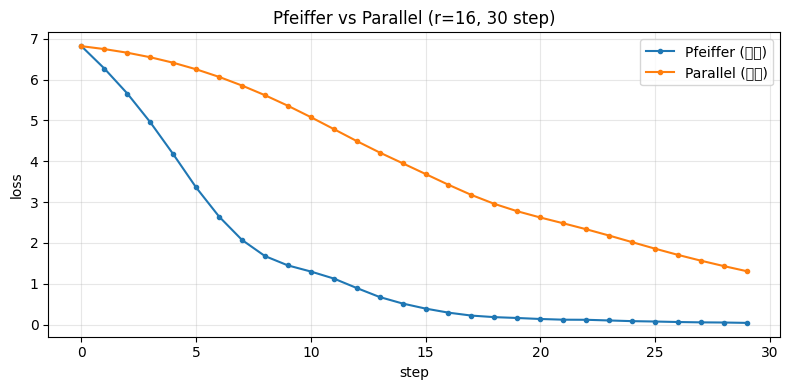

In [2]:
torch.manual_seed(42)
pfe = PfeifferGPT2(r=16)
torch.manual_seed(42)
par = ParallelAdapterGPT2(r=16)

tok = pfe.tokenizer
inputs = tok([
    'hello world this is a test', 'i love this amazing product',
    'absolutely terrible movie', 'fantastic experience'
], return_tensors='pt', padding=True)
inputs['labels'] = inputs['input_ids'].clone()

models = [
    ('Pfeiffer (串联)', pfe, torch.optim.AdamW([p for p in pfe.parameters() if p.requires_grad], lr=1e-3)),
    ('Parallel (并联)', par, torch.optim.AdamW([p for p in par.parameters() if p.requires_grad], lr=1e-3)),
]

losses = {n: [] for n, _, _ in models}
for step in range(30):
    for name, m, opt in models:
        opt.zero_grad()
        out = m(**inputs)
        out.loss.backward()
        opt.step()
        losses[name].append(out.loss.item())

plt.figure(figsize=(8, 4))
for n in losses:
    plt.plot(losses[n], label=n, marker='o', markersize=3)
plt.xlabel('step'); plt.ylabel('loss')
plt.title('Pfeiffer vs Parallel (r=16, 30 step)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2. 验证：去掉非线性 = LoRA

In [3]:
# 在小尺寸上手动验证：Parallel(σ=identity) ≡ LoRA
import torch.nn as nn

d, r = 8, 2
torch.manual_seed(0)
x = torch.randn(1, 4, d)

# Parallel without nonlinearity
base = nn.Linear(d, d, bias=False)
W_down = nn.Linear(d, r, bias=False)
W_up = nn.Linear(r, d, bias=False)
torch.manual_seed(123)
for p in [base, W_down, W_up]:
    for layer_p in p.parameters():
        nn.init.normal_(layer_p, std=0.1)

# Parallel without σ
out_parallel = base(x) + W_up(W_down(x))

# LoRA equivalent: 等价于 base + (W_up @ W_down) @ x
delta_W = W_up.weight @ W_down.weight  # (d, d), rank=r
out_lora = base(x) + (x @ delta_W.T)

diff = (out_parallel - out_lora).abs().max().item()
print(f'Parallel (no σ) vs LoRA 最大误差: {diff:.4e}')
print(f'→ 严格相等：Parallel without σ = LoRA')
print(f'\ndelta_W shape: {delta_W.shape}, rank: {torch.linalg.matrix_rank(delta_W).item()}')

Parallel (no σ) vs LoRA 最大误差: 5.9605e-08
→ 严格相等：Parallel without σ = LoRA

delta_W shape: torch.Size([8, 8]), rank: 2


## 3. minimal vs adapters 库

In [4]:
from parallel_adapters import build_parallel_model
lib = build_parallel_model(reduction_factor=48)
n_par = sum(p.numel() for p in par.parameters() if p.requires_grad)
n_lib = sum(p.numel() for p in lib.parameters() if p.requires_grad)
print(f'minimal: {n_par:,}')
print(f'lib:     {n_lib:,}')
print(f'match: {n_par == n_lib}')

W0603 17:06:57.947000 34784 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


There are adapters available but none are activated for the forward pass.


minimal: 304,320
lib:     304,320
match: True


## 4. 思考题

1. 修改 scaling 从 1.0 到 4.0，观察收敛差异。
2. 实现 "Parallel + 去 σ" 的版本，确认与 LoRA 数值一致。
3. 把 Parallel adapter 用到 attention 上而不是 FFN，看效果。

下节: **(IA)³** — 极致压缩